In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from sklearn.metrics import roc_auc_score
from torch.nn.functional import softmax
from sklearn.model_selection import StratifiedShuffleSplit

In [2]:
# ─── Device Setup ────────────────────────────────────────────────────────────
try:
    import torch_directml
    device = torch_directml.device()
    print(f"Using device: {device}")
except Exception:
    device = torch.device('cpu')
    print("Using device: CPU")

Using device: privateuseone:0


In below cell, I have iterated through all the images in all subfolders and labelled them to train the model. 

In [3]:
folder_path = "../dataset"
types = ['no', 'sphere', 'vort']

class NPYDataset(Dataset):

    def __init__(self, split):
        self.data = []
        self.labels = []

        for t in types:
            path = os.path.join(folder_path, split, t)
            label = types.index(t)
            # if t == "no":
            #     label = 0
            # elif t == "sphere":
            #     label = 1
            # else:
            #     label = 2
            for file in os.listdir(path):
                arr = np.load(os.path.join(path, file))
                # convert shape (1,150,150) -> (150,150,1)
                arr = np.transpose(arr, (1,2,0))
                self.data.append(arr)
                self.labels.append(label)
        self.data = np.array(self.data, dtype=np.float32)
        self.labels = np.array(self.labels)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        x = torch.tensor(self.data[idx]).permute(2,0,1)  # HWC -> CHW
        y = torch.tensor(self.labels[idx]).long()

        return x, y

Below cell creates a split/fraction of the dataset for the model to be trained easily. 

In [4]:
from torch.utils.data import Subset

def get_stratified_subset(dataset, fraction):
    """
    Returns a Subset that contains `fraction` of the data
    while preserving the original class distribution (stratified).
    
    Example: if your full dataset is 40% 'no', 30% 'sphere', 30% 'vort',
    the subset will also be ~40/30/30 — not randomly skewed.
    """
    labels = dataset.labels
    splitter = StratifiedShuffleSplit(n_splits=1, test_size=fraction, random_state=42)
    
    # StratifiedShuffleSplit gives us the *test* indices as our subset
    _, subset_idx = next(splitter.split(np.zeros(len(labels)), labels))
    
    return Subset(dataset, subset_idx)

In below cell, I have split the dataset into fraction. The 'FRACTION' variable decides how much data the model sees. Lowest could be 10% or 0.1 because anything less than that, the model might not be able to identify patterns. This has been done to test the model, so that all trail and erroring can be done in an easy and quick way when required. When the testing is done, the FRACTION will be changed to 1 to include full dataset. 

In [5]:
batch_size = 32

train_dataset = NPYDataset("train")
val_dataset   = NPYDataset("val")

# ── Fraction of data to use (e.g. 0.1 = 10%) ──────────────────────────────
FRACTION = 0.1   # change this when ready for full training

train_subset = get_stratified_subset(train_dataset, FRACTION)
val_subset   = get_stratified_subset(val_dataset,   FRACTION)

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_subset,   batch_size=batch_size)

print(f"Train samples: {len(train_subset)} / {len(train_dataset)}")
print(f"Val   samples: {len(val_subset)}   / {len(val_dataset)}")

Train samples: 3000 / 30000
Val   samples: 750   / 7500


In [6]:
batch_size = 32
train_dataset = NPYDataset("train")
val_dataset = NPYDataset("val")
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

In below cell, I have defined the model. 

In [7]:
class Model(nn.Module):

    def __init__(self):
        super().__init__()

        resnet = models.resnet18(weights=None)

        # modify first layer for 1 channel
        resnet.conv1 = nn.Conv2d(
            1, 64, kernel_size=7, stride=2, padding=3, bias=False
        )

        # remove classifier
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])

        width = 128

        self.head = nn.Sequential(
            nn.Linear(512, width*8),
            nn.ReLU(),
            nn.LayerNorm(width*8),
            nn.Dropout(0.5),

            nn.Linear(width*8, width*4),
            nn.ReLU(),
            nn.LayerNorm(width*4),
            nn.Dropout(0.5),

            nn.Linear(width*4, width),
            nn.ReLU(),
            nn.LayerNorm(width),
            nn.Dropout(0.3),

            nn.Linear(width, 3)
        )

        for m in resnet.modules():
            if isinstance(m, nn.BatchNorm2d):
                m.eval()
                m.requires_grad_(False)

    def forward(self, x):

        x = self.backbone(x)
        x = torch.flatten(x, 1)
        x = self.head(x)

        return x

In below cell, optimizers and model instantiation has been applied. 

In [8]:
model = Model().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [9]:
# Training loop 
num_epochs = 30
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for X, y in train_loader:
        X = X.to(device)
        y = y.to(device)
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    # Validation
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in val_loader:
            X = X.to(device)
            y = y.to(device)
            outputs = model(X)
            loss = criterion(outputs, y)
            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    val_loss /= len(val_loader)
    val_acc = correct / total
    print(
        f"Epoch {epoch+1}/{num_epochs} "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )

d:\GSoC\DeepLense\DeepLense\Lib\site-packages\torch\optim\adam.py:534: UserWarning: The operator 'aten::lerp.Scalar_out' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  torch._foreach_lerp_(device_exp_avgs, device_grads, 1 - beta1)


Epoch 1/30 Train Loss: 1.1194 Val Loss: 1.0997 Val Acc: 0.3333
Epoch 2/30 Train Loss: 1.1016 Val Loss: 1.0984 Val Acc: 0.3357


KeyboardInterrupt: 

In [ ]:
model.eval()

Model(
  (backbone): Sequential(
    (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


In [ ]:
import numpy as np

all_preds = []
all_labels = []

with torch.no_grad():
    
    for X, y in val_loader:
        
        X = X.to(device)
        y = y.to(device)

        outputs = model(X)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

In [ ]:
import torch
import numpy as np
import torch.nn.functional as F

model.eval()

test_loss = 0
mae = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():

    for X, y in val_loader:   # use test_loader if you have one

        X = X.to(device)
        y = y.to(device)

        outputs = model(X)

        loss = criterion(outputs, y)
        test_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        mae += torch.abs(preds - y).sum().item()

        total += y.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

test_loss /= len(val_loader)
mae /= total

print(f"Test Loss: {test_loss:.4f}, Test MAE: {mae:.4f}")

Test Loss: 0.5467, Test MAE: 0.1908


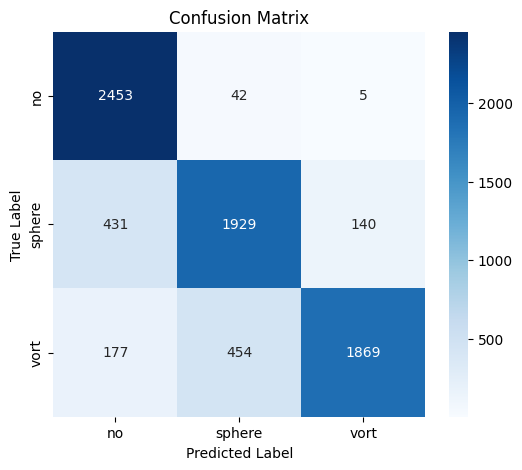

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# convert lists to arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# plot heatmap
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["no","sphere","vort"],
    yticklabels=["no","sphere","vort"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score

model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for X, y in val_loader:
        X = X.to(device)
        y = y.to(device)
        
        outputs = model(X)
        probs = F.softmax(outputs, dim=1)
        
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# Convert to numpy arrays
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# Compute AUC for multi-class (one-vs-rest)
auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
print(f"AUC (One-vs-Rest): {auc:.4f}")

# For macro average
auc_macro = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
print(f"AUC Macro Average: {auc_macro:.4f}")

In [ ]:
# # ─── Save Model ───────────────────────────────────────────────────────────────
# torch.save(model.state_dict(), "model_supervised.pth")
# print("Model saved to model_supervised.pth")